# The Proximal Policy Optimization (PPO) Cookbook

## 1. The Necessity: Why PPO Exists

### 1.1 The Policy Gradient Problem: Instability

All Policy Gradient (PG) methods (like REINFORCE) maximize the expected return $J(\theta)$ by taking gradient steps:

$$\nabla_{\theta} J(\theta) \propto \mathbb{E} \left[ \nabla_{\theta} \log \pi_{\theta}(a_t | s_t) A_t \right]$$

This formula says: Increase the probability of actions $a_t$ that had a positive **Advantage** $A_t$.

The core issue is that PG methods are **On-Policy**: they use data collected by the current policy $\pi_{\theta_{old}}$. After one gradient update, the policy changes to $\pi_{\theta_{new}}$. If the update is too large, the new policy is unstable (falls "off a cliff"), and the old data is no longer representative.

### 1.2 The TRPO and PPO Solution: Proximity

**Goal:** Take the biggest possible improvement step without changing the policy too much. We must stay **proximal** (close) to the old policy.

* **TRPO (Trust Region Policy Optimization):** Used a complex mathematical constraint (KL divergence) to enforce this proximity. Too hard to implement.
* **PPO (Proximal Policy Optimization):** Achieves the same stability by putting the constraint **directly into the optimization objective**, using a simple **clipping** mechanism.

## 2. PPO: Step-by-Step Mathematical Derivation

### Step 1: The Surrogate Objective (Importance Sampling)

To reuse the old data for multiple gradient updates (increasing **sample efficiency**), we use **Importance Sampling** to evaluate the new policy $\pi_{\theta}$ using data collected from $\pi_{\theta_{old}}$.

We define the **Probability Ratio** $r_t(\theta)$:

$$r_t(\theta) = \frac{\pi_{\theta}(a_t | s_t)}{\pi_{\theta_{old}}(a_t | s_t)}$$

The surrogate objective to maximize is:

$$L^{SURROGATE}(\theta) = \mathbb{E}_{s_t, a_t \sim \pi_{\theta_{old}}} \left[ r_t(\theta) \hat{A}_t \right]$$

* $\hat{A}_t$ is the estimated Advantage (usually computed using the Critic Network and GAE).
* If $r_t(\theta) > 1$, the action $a_t$ is more likely under the new policy. If $\hat{A}_t > 0$, this is good.
* If $r_t(\theta)$ is very large, the gradient is too aggressive, leading to the instability problem.

### Step 2: The Clipped Surrogate Objective (The Safety Fence)

This is the core innovation of PPO. We introduce a hyperparameter $\epsilon$ (e.g., $0.1$ or $0.2$) to define a "trust region." We want the ratio $r_t(\theta)$ to stay within $[1-\epsilon, 1+\epsilon]$.

The **Clipping Function** $\text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)$ clamps the ratio within this range.

The final **Clipped Surrogate Objective** $L^{CLIP}(\theta)$ is defined as:

$$L^{CLIP}(\theta) = \mathbb{E}_{s_t, a_t \sim \pi_{\theta_{old}}} \left[ \min(r_t(\theta) \hat{A}_t, \ \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) \hat{A}_t) \right]$$

**Intuition of the $\min$ Operator:**

The $\min$ function chooses the lower bound (the more **pessimistic** estimate) between the unclipped and the clipped objective.

* **Case 1: Positive Advantage ($\hat{A}_t > 0$, Good Action):**
    * We want $r_t(\theta)$ to increase.
    * If $r_t(\theta)$ goes above $1+\epsilon$, the term $\text{clip}(r_t(\theta), \dots) \hat{A}_t$ stops growing.
    * The $\min$ function will choose the clipped term, $\mathbf{(1+\epsilon)\hat{A}_t}$. This **removes the incentive** for the policy to make $r_t(\theta)$ any larger, preventing a huge step.

* **Case 2: Negative Advantage ($\hat{A}_t < 0$, Bad Action):**
    * We want $r_t(\theta)$ to decrease (to be closer to $0$).
    * If $r_t(\theta)$ goes below $1-\epsilon$, the term $r_t(\theta) \hat{A}_t$ will become a very large positive number (since $\hat{A}_t$ is negative). This would aggressively increase the loss and push the policy to change too much.
    * The $\min$ function will choose the unclipped term, $\mathbf{r_t(\theta) \hat{A}_t}$, but only until the clipped term becomes smaller. In this case, when $r_t(\theta) < 1-\epsilon$, the clipped term is $(1-\epsilon)\hat{A}_t$, which is a **more negative** (i.e., smaller) number than $r_t(\theta) \hat{A}_t$. The $\min$ function limits the improvement to $\mathbf{(1-\epsilon)\hat{A}_t}$. This **prevents the policy from drastically dropping** the probability of the action.

The clipping ensures the policy update is always **conservative and stable**.

### Step 3: The Full PPO Loss Function

PPO uses the **Actor-Critic** architecture (two networks: **Actor** $\pi_{\theta}$ for policy, **Critic** $V_{\phi}$ for value prediction). The full loss to be **MINIMIZED** is:

$$L^{PPO}(\theta, \phi) = - L^{CLIP}(\theta) + c_1 L^{VF}(\phi) - c_2 L^{ENTROPY}(\theta)$$

1.  **Policy Loss (Maximize $L^{CLIP}$):** We use the negative sign $-L^{CLIP}(\theta)$ because we are performing gradient **descent** on the loss function, but we want to **maximize** the objective.
2.  **Value Function Loss ($L^{VF}$):** The Mean Squared Error (MSE) between the Critic's prediction $V_{\phi}(s_t)$ and the actual target $R_t$ (the empirical return):
    $$L^{VF}(\phi) = \mathbb{E}_{s_t} \left[ (V_{\phi}(s_t) - R_t)^2 \right]$$
3.  **Entropy Bonus ($L^{ENT}$):** A term to encourage **exploration** (high uncertainty in the action distribution). It is subtracted from the loss, encouraging the optimizer to increase entropy.

## 3. PPO Algorithm and Example Walkthrough

### Algorithm Flow

1.  **Collect Rollout:** The agent (using **Old Policy** $\pi_{\theta_{old}}$) interacts with the environment for $T$ steps, storing data (state, action, reward, value prediction, log probability).
2.  **Compute Targets:** Calculate the **Advantage** $\hat{A}_t$ (using GAE) and the **Return** $R_t$ for the batch.
3.  **Optimize (K Epochs):** The agent runs $K$ epochs of gradient descent on the *same batch* of data, minimizing the $L^{PPO}$ loss.
4.  **Update Policy:** Set $\pi_{\theta_{old}} \leftarrow \pi_{\theta_{new}}$ and repeat.

### Example: The Clipping in Action ($\epsilon=0.2$)

Let's look at a single state-action pair $(s, a)$ in the classic **CartPole** environment, where the agent is learning to apply force (Left or Right) to keep a pole balanced.

| Metric | Value | Meaning |
| :--- | :--- | :--- |
| **Old Policy Prob** ($\pi_{\theta_{old}}$) | $0.1$ | The old policy was unlikely to choose action 'Right'. |
| **New Policy Prob** ($\pi_{\theta_{new}}$) | $0.35$ | The new policy is much more likely to choose action 'Right'. |
| **Advantage** ($\hat{A}_t$) | $+10.0$ | This action 'Right' was *very good* (e.g., it prevented the pole from falling). |
| **Epsilon** ($\epsilon$) | $0.2$ | Clipping range is $[0.8, 1.2]$. |

| Calculation | Result | Interpretation |
| :--- | :--- | :--- |
| **Ratio $r_t(\theta)$** | $\frac{0.35}{0.1} = \mathbf{3.5}$ | The new policy is **$3.5$ times** more likely to take this action. (Too aggressive!) |
| **$1+\epsilon$** | $1.2$ | The upper limit of the "trust region." |
| **Term 1 (Unclipped)** | $r_t(\theta) \hat{A}_t = 3.5 \times 10.0 = \mathbf{35.0}$ | The full, aggressive improvement step. |
| **Term 2 (Clipped)** | $\text{clip}(3.5, 0.8, 1.2) \times 10.0 = 1.2 \times 10.0 = \mathbf{12.0}$ | The safe, limited improvement step. |
| **$L^{CLIP}$ Objective** | $\min(35.0, 12.0) = \mathbf{12.0}$ | **PPO chooses the smaller value (12.0).** It ignores the huge, unstable value of 35.0, preventing the new policy from moving too far, too fast. |

**Conclusion:** Even though the new policy *wants* to change the probability by $350\%$, PPO’s clip function limits the benefit it can get from this single experience to a $120\%$ change, ensuring the policy update is stable and within the trust region.

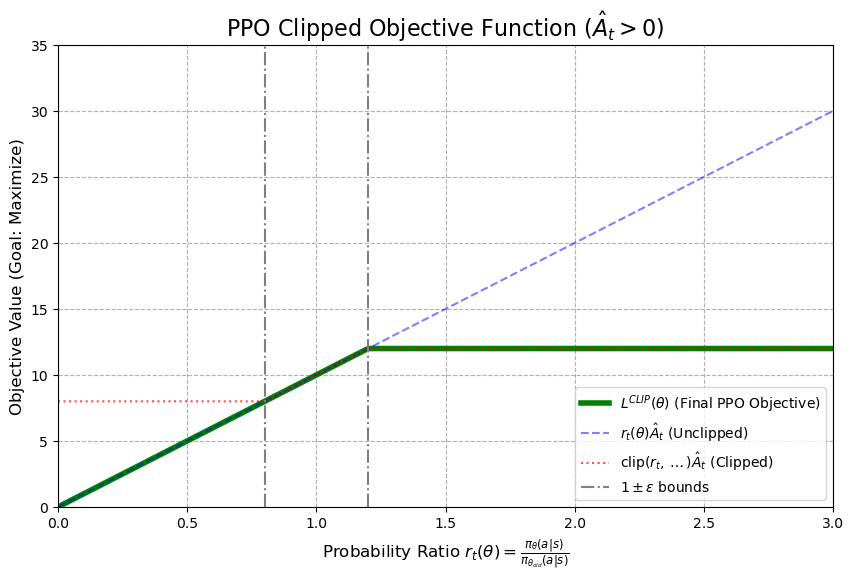

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------- Setup -----------------
epsilon = 0.2
advantage = 10  # Positive Advantage: The action was good!
ratio = np.linspace(0, 5, 500) # Range of possible probability ratios (r_t)

# ----------------- 1. Calculate Unclipped Objective -----------------
# L_surrogate = r_t * A_t
unclipped_objective = ratio * advantage

# ----------------- 2. Calculate Clipped Objective -----------------
# clipped_ratio = clip(r_t, 1-eps, 1+eps)
clipped_ratio = np.clip(ratio, 1 - epsilon, 1 + epsilon)
clipped_objective = clipped_ratio * advantage

# ----------------- 3. Calculate PPO Loss (min of two terms) -----------------
ppo_loss = np.minimum(unclipped_objective, clipped_objective)

# ----------------- Plotting -----------------
plt.figure(figsize=(10, 6))

# Plot PPO Loss (The final objective PPO maximizes)
plt.plot(ratio, ppo_loss, label='$L^{CLIP}(\\theta)$ (Final PPO Objective)', 
         color='green', linewidth=4)

# Plot Unclipped Term (r_t * A_t)
plt.plot(ratio, unclipped_objective, '--', label='$r_t(\\theta) \hat{A}_t$ (Unclipped)', 
         color='blue', alpha=0.5)

# Plot Clipped Term (clip * A_t)
plt.plot(ratio, clipped_objective, ':', label='$\\text{clip}(r_t, \\dots) \hat{A}_t$ (Clipped)', 
         color='red', alpha=0.7)

# Highlight Clipping Region
plt.axvline(1 - epsilon, color='gray', linestyle='-.', label='$1 \pm \epsilon$ bounds')
plt.axvline(1 + epsilon, color='gray', linestyle='-.')
plt.axhline(0, color='black', linewidth=0.5) # Zero line

# Add Annotations
plt.title('PPO Clipped Objective Function ($\hat{A}_t > 0$)', fontsize=16)
plt.xlabel('Probability Ratio $r_t(\\theta) = \\frac{\\pi_{\\theta}(a|s)}{\\pi_{\\theta_{old}}(a|s)}$', fontsize=12)
plt.ylabel('Objective Value (Goal: Maximize)', fontsize=12)
plt.xlim(0, 3)
plt.ylim(0, 35)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--')
plt.show()

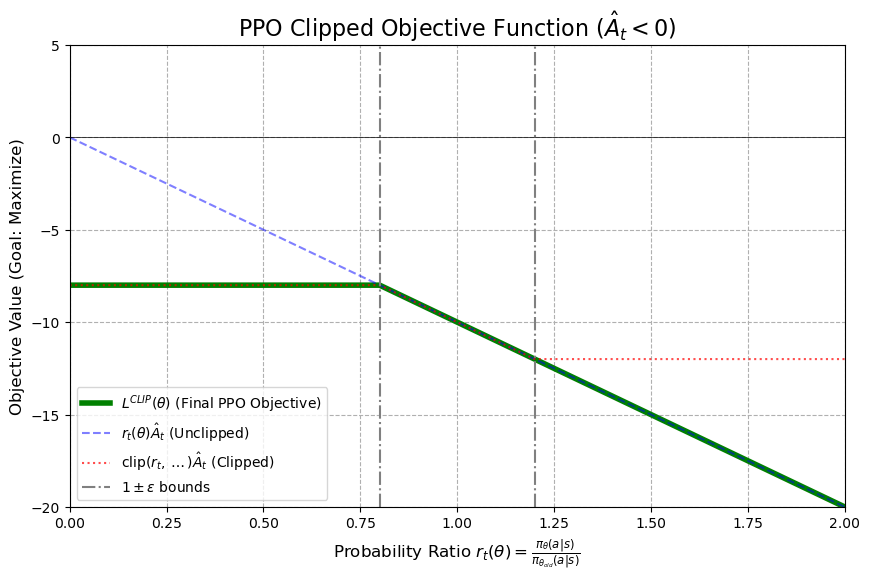

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------- Setup -----------------
epsilon = 0.2
advantage = -10  # Negative Advantage: The action was bad!
ratio = np.linspace(0, 2, 500) # Range of possible probability ratios (r_t)

# ----------------- 1. Calculate Unclipped Objective -----------------
# L_surrogate = r_t * A_t
unclipped_objective = ratio * advantage

# ----------------- 2. Calculate Clipped Objective -----------------
# clipped_ratio = clip(r_t, 1-eps, 1+eps)
clipped_ratio = np.clip(ratio, 1 - epsilon, 1 + epsilon)
clipped_objective = clipped_ratio * advantage

# ----------------- 3. Calculate PPO Loss (min of two terms) -----------------
# Note: Since A_t is negative, the "minimum" now corresponds to the less negative (or higher) value.
# The min operator is still correct for finding the pessimistic estimate.
ppo_loss = np.minimum(unclipped_objective, clipped_objective)

# ----------------- Plotting -----------------
plt.figure(figsize=(10, 6))

# Plot PPO Loss (The final objective PPO maximizes)
plt.plot(ratio, ppo_loss, label='$L^{CLIP}(\\theta)$ (Final PPO Objective)', 
         color='green', linewidth=4)

# Plot Unclipped Term (r_t * A_t)
plt.plot(ratio, unclipped_objective, '--', label='$r_t(\\theta) \hat{A}_t$ (Unclipped)', 
         color='blue', alpha=0.5)

# Plot Clipped Term (clip * A_t)
plt.plot(ratio, clipped_objective, ':', label='$\\text{clip}(r_t, \\dots) \hat{A}_t$ (Clipped)', 
         color='red', alpha=0.7)

# Highlight Clipping Region
plt.axvline(1 - epsilon, color='gray', linestyle='-.', label='$1 \pm \epsilon$ bounds')
plt.axvline(1 + epsilon, color='gray', linestyle='-.')
plt.axhline(0, color='black', linewidth=0.5) # Zero line

# Add Annotations
plt.title('PPO Clipped Objective Function ($\hat{A}_t < 0$)', fontsize=16)
plt.xlabel('Probability Ratio $r_t(\\theta) = \\frac{\\pi_{\\theta}(a|s)}{\\pi_{\\theta_{old}}(a|s)}$', fontsize=12)
plt.ylabel('Objective Value (Goal: Maximize)', fontsize=12)
plt.xlim(0, 2)
plt.ylim(-20, 5)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--')
plt.show()